In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib as mpl

# Set default plot properties (rcParams)
plt.rcParams['figure.figsize'] = [15, 8]  # Set the default figure size (width, height)
plt.rcParams['figure.dpi'] = 300  # Set the resolution (300 DPI for high-quality output)
plt.rcParams['lines.linewidth'] = 1     # Set default line width
plt.rcParams['lines.color'] = 'b'         # Set default line color (blue in this case)
plt.rcParams['axes.grid'] = True 
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.alpha'] = 0.3    
plt.rcParams['axes.titlecolor'] = '#616161'
plt.rcParams['axes.labelcolor'] = '#616161'
plt.rcParams['xtick.color'] = '#616161'
plt.rcParams['ytick.color'] = '#616161'
plt.rcParams['text.color'] = '#616161'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.markerscale'] = 1
plt.rcParams['legend.framealpha'] = 0.5
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#BCCF02", "#6C9C30", "#3E5C17", "#a7b805"]) 
# plt.rcParams["patch.facecolor"] = "#BCCF02"

plt.rcParams['figure.constrained_layout.use'] = True # alternativ zu tight_layout(). noch testen sonst deaktivieren

In [7]:
import pandas as pd


spot_path = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\01_raw\spot_ch_25.xlsx'
HEADER_ROW_SPOT     = 0
df_spot = pd.read_excel(spot_path, header=HEADER_ROW_SPOT)
spot_column = 'Spot CH [Euro/MWh]'

df_spot['UTC'] = pd.to_datetime(df_spot['UTC'], utc=True)
df_spot.set_index('UTC', inplace=True)
spot_price_series = df_spot['Spot CH [Euro/MWh]']



galliker_25 = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\San_Antonino\Galliker-btm\galliker_san_antonino_2025.csv'
galliker_26 = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\San_Antonino\Galliker-btm\galliker_san_antonino_2026.csv'
df_galliker_25 = pd.read_csv(galliker_25)
df_galliker_26 = pd.read_csv(galliker_26)

# Explicitly parse the timestamp column as UTC-aware datetimes
df_galliker_25['timestamp'] = pd.to_datetime(df_galliker_25['timestamp'], utc=True)
df_galliker_26['timestamp'] = pd.to_datetime(df_galliker_26['timestamp'], utc=True)

# Convert from UTC to Europe/Zurich local time
df_galliker_25['timestamp'] = df_galliker_25['timestamp'].dt.tz_convert('Europe/Zurich')
df_galliker_26['timestamp'] = df_galliker_26['timestamp'].dt.tz_convert('Europe/Zurich')

df_galliker_25.set_index(df_galliker_25['timestamp'], inplace=True)
df_galliker_26.set_index(df_galliker_26['timestamp'], inplace=True)
df_galliker_25.drop(columns='timestamp', inplace=True)
df_galliker_26.drop(columns='timestamp', inplace=True)
df_galliker = pd.concat([df_galliker_25, df_galliker_26], axis=0).sort_index()
df_galliker[spot_column] = spot_price_series
df_galliker.head(5)

df_results = df_galliker

In [ ]:


# monthly peak: grid_peak_shave__var_peak_power (incl. bess) -> min()

# bess bess_san_antonino__var_power_discharge, bess_san_antonino__var_power_charge, bess_san_antonino__var_power
# if bess_san_antonino__var_power is negative we charge (so all power flows which are negative take energy from the grid and if flow is positive we give energy)
# bess soc bess_san_antonino__var_soc_slot_start (tracking)

# PV spill = curtailement: PV_San_Antonino__var_spill
# PV_San_Antonino__var_power -> always positive = always power flow towards the grid

# Building -> lost load = curtailement: San_Antonino__var_lost_load
# San_Antonino__var_power -> load profile building

# check if bess power is integrated in San_Antonino__var_power -> btm construct built correctly
# I think bess is only visible in grid and spot powers, because we are looking at the power of the indivudual components and only in grid it is aggregated
# evt total is grid_peak_shave__var_power_export, grid_peak_shave__var_power_import

# Prices: if bess is correctly btm we have total costs as spot_ch__var_power * 0.25 (get energy) * price (from df_spot prices)
# check if spot_ch__var_power (incl. the sign) should be equal to (grid_peak_shave__var_power_export, -grid_peak_shave__var_power_import)
# when spot_ch__var_power negative we pay (import energy) and if positive we receive

# dayly, weekly,monthly total costs = spot_ch__var_power * spot_prices sum
# look at bess alone  bess_san_antonino__var_power * spot_prices (when negative we are charging)
# look at system without bess (PV_San_Antonino__var_power + San_Antonino__var_power) * spot_prices # peaks without bess = (PV_San_Antonino__var_power + San_Antonino__var_power).min(month)
# look at system with bess spot_ch__var_power * spot_prices

# indivudal graph
# visualize the peak loads with and without bess per month as a graph
# also calculate the peak costs with and without bess 



# individual graph 
# visualize the total load of the simulation with bess spot_ch__var_power and without bess PV_San_Antonino__var_power + San_Antonino__var_power
# in the same plot so that we can compare it

# individual graph
# visualize the total costs with and without bess per month and over the entire year (incl. peak costs of the month per case (with bess and without))

# individual graph
# make it modular so that one can add different lines from the simulation df_ (start with soc_slot_start, spot_prices)


# columns
# PV_San_Antonino__var_power + San_Antonino__var_power, grid_peak_shave__var_power_export, -grid_peak_shave__var_power_import, spot_ch__var_power
# bess_san_antonino__var_power_charge, bess_san_antonino__var_power

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

DT_HOURS = 0.25  # 15-min slot length in hours


def energy_cost(power_mw: pd.Series, spot_price_eur_mwh: pd.Series,
                 fee_import: float, fee_export: float,
                 front_of_meter: bool = False, bess_active=False,
                 pv_col=None, building_col=None, bess_col=None) -> pd.Series:
    """Cost per timestep (CHF), given power in MW (negative = import/pay, positive = export/receive).

    Import price = spot + fee_import ; Export price = spot + fee_export (fee_export usually 0).
    We multiplied by -1 to make positive values being costs

    edge case: import fees for PV and building but not for bess (is virutalized)
    """
    if front_of_meter:
        power_with_fee = pv_col + building_col
        price_pv_build = spot_price_eur_mwh.where(power_with_fee >= 0, spot_price_eur_mwh + fee_export)
        price_pv_build = price_pv_build.where(power_with_fee < 0, spot_price_eur_mwh + fee_import)

        cost_pv_build = power_with_fee * price_pv_build   # <-- multiply by power, this was missing
        if bess_active:
            cost_bess     = bess_col * spot_price_eur_mwh
        else:
            cost_bess = 0
        return (cost_bess + cost_pv_build) * DT_HOURS * -1

    price = spot_price_eur_mwh.where(power_mw >= 0, spot_price_eur_mwh + fee_export)
    price = price.where(power_mw < 0, spot_price_eur_mwh + fee_import)
    return power_mw * DT_HOURS * price * -1  # -1: negative power (import) -> positive cost


def monthly_peak(power_mw: pd.Series) -> pd.Series:
    """Monthly peak import (MW, positive value) — import is negative power, so peak = -min()."""
    return power_mw.groupby(power_mw.index.to_period('M')).min().mul(-1)


def peak_cost(peak_mw: pd.Series, price_per_mw: float) -> pd.Series:
    """Peak demand charge per month (CHF) = peak (MW) * price (CHF/MW)."""
    return peak_mw * price_per_mw


def plot_timeseries_columns(df: pd.DataFrame, columns: list[str], title: str,
                             ylabel: str = "Value", figsize=(12, 5)):
    """Modular line plot — plot any set of df columns over time."""
    fig, ax = plt.subplots(figsize=figsize, dpi=130)
    for col in columns:
        ax.plot(df.index, df[col], label=col, linewidth=1.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    return fig


In [16]:
kosten_lastspitze = 7190      # 7190 CHF/MW   
arbeitspreis_netz_bezug = 42.4    # 42.4 CHF/MWh 
arbeitspreis_netz_einspeisung = 0

Anschlussleistung_SanAntonino = 1.6  # MW
cos_phi = 0.86
Anschlussleistung_Schachen = 0.935 * cos_phi  # MW

# ── Core power series ───────────────────────────────────────────────────────
power_with_bess    = df_results['spot_ch__var_power']
power_with_bess    = df_results['bess_san_antonino__var_power']
power_without_bess = df_results['San_Antonino__var_power'] + df_results['PV_San_Antonino__var_power']

spot_prices = spot_price_series  # your aligned EUR/MWh series, same index

# ── Energy costs ─────────────────────────────────────────────────────────────
# behind the meter: power_with_bess = spot_CH__var_power, edge case = False, power_without_bess = load building + load PV
# front of meter: edge case = true, power_without_bess = load building + load PV
cost_with_bess    = energy_cost(power_with_bess, spot_prices, arbeitspreis_netz_bezug, arbeitspreis_netz_einspeisung,
                                front_of_meter=True, bess_active=True,
                                pv_col=df_results['PV_San_Antonino__var_power'], building_col=df_results['San_Antonino__var_power'], bess_col=df_results['bess_san_antonino__var_power'])
cost_without_bess = energy_cost(power_without_bess, spot_prices, arbeitspreis_netz_bezug, arbeitspreis_netz_einspeisung,
                                front_of_meter=True, bess_active=False,
                                pv_col=df_results['PV_San_Antonino__var_power'], building_col=df_results['San_Antonino__var_power'], bess_col=None)

monthly_energy_cost = pd.DataFrame({
    'with_bess': cost_with_bess.groupby(cost_with_bess.index.to_period('M')).sum(),
    'without_bess': cost_without_bess.groupby(cost_without_bess.index.to_period('M')).sum(),
})

# ── Peaks & peak costs ────────────────────────────────────────────────────────

# When virualizing the peak costs only from the areal, thus equal between both cases!

peaks = pd.DataFrame({
    'with_bess': monthly_peak(power_with_bess),
    'without_bess': monthly_peak(power_without_bess),
})
peak_costs = peaks.apply(lambda col: peak_cost(col, kosten_lastspitze))

monthly_total_cost = monthly_energy_cost + peak_costs
print("Annual total cost — with BESS:", monthly_total_cost['with_bess'].sum().round(0), "CHF")
print("Annual total cost — without BESS:", monthly_total_cost['without_bess'].sum().round(0), "CHF")

Annual total cost — with BESS: 282492.0 CHF
Annual total cost — without BESS: 386923.0 CHF


C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\67707307.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  'with_bess': cost_with_bess.groupby(cost_with_bess.index.to_period('M')).sum(),
C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\67707307.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  'without_bess': cost_without_bess.groupby(cost_without_bess.index.to_period('M')).sum(),
C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\1884924857.py:37: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return power_mw.groupby(power_mw.index.to_period('M')).min().mul(-1)


C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\395121271.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


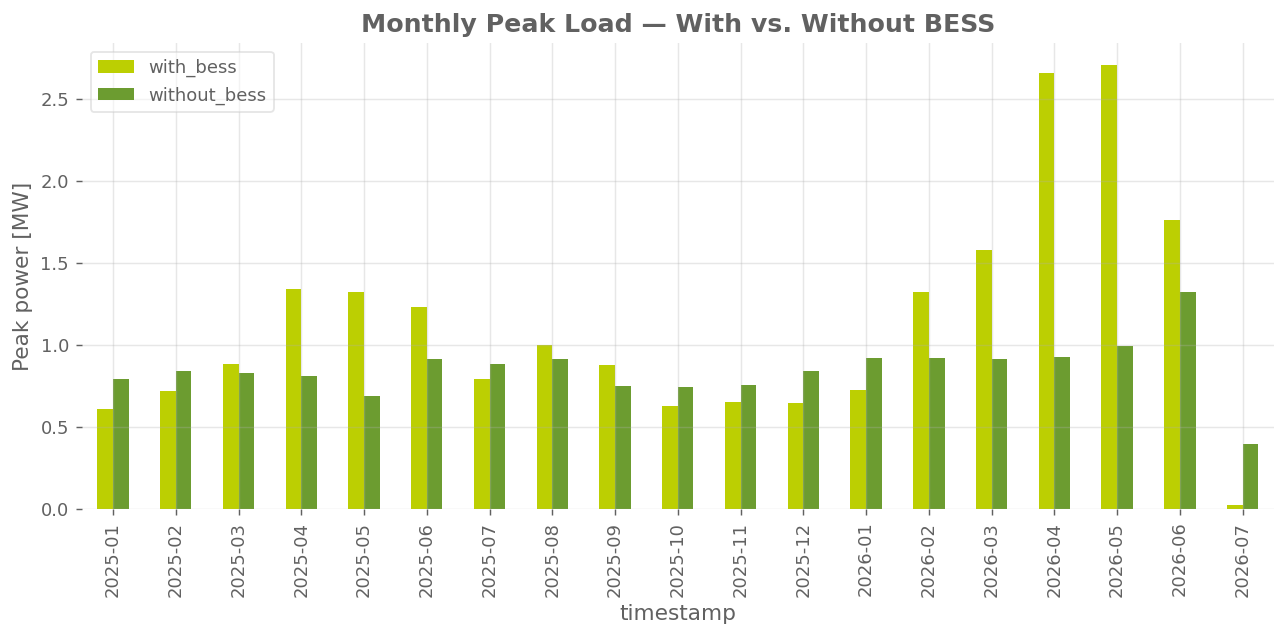

C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\1884924857.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


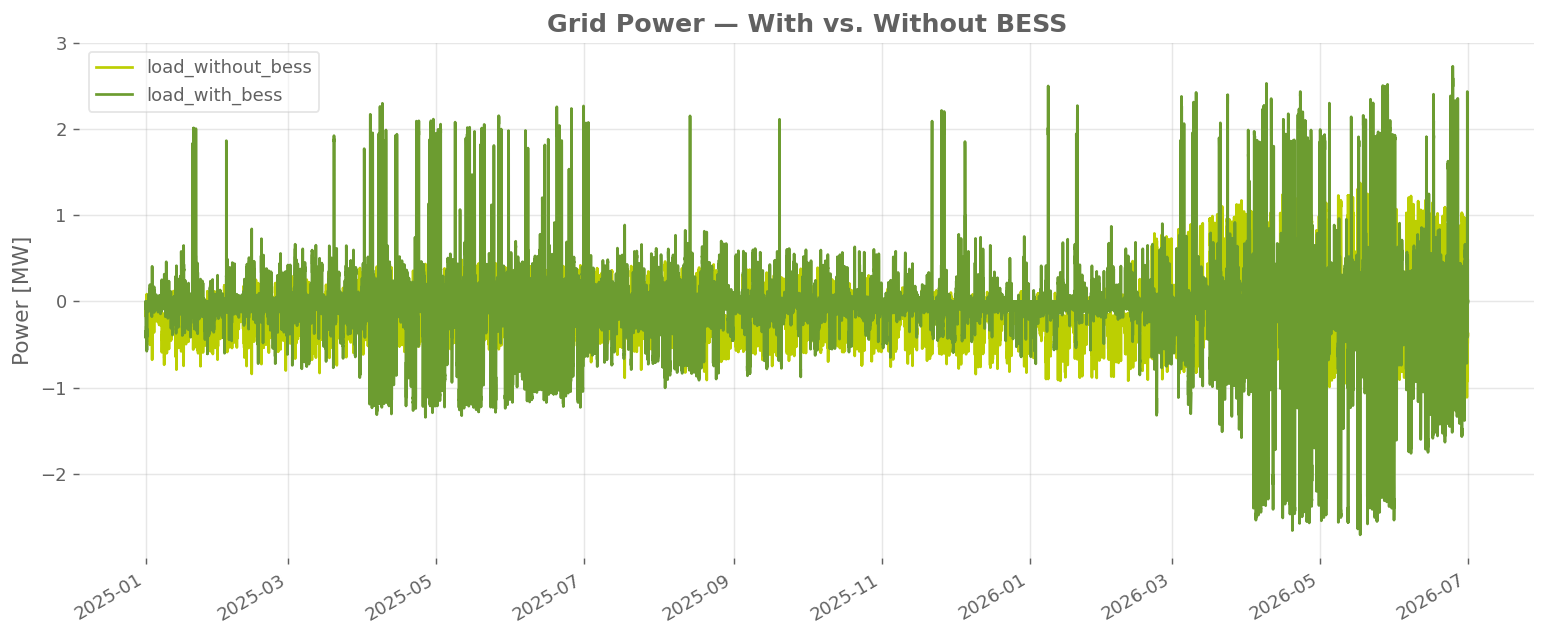

C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\395121271.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


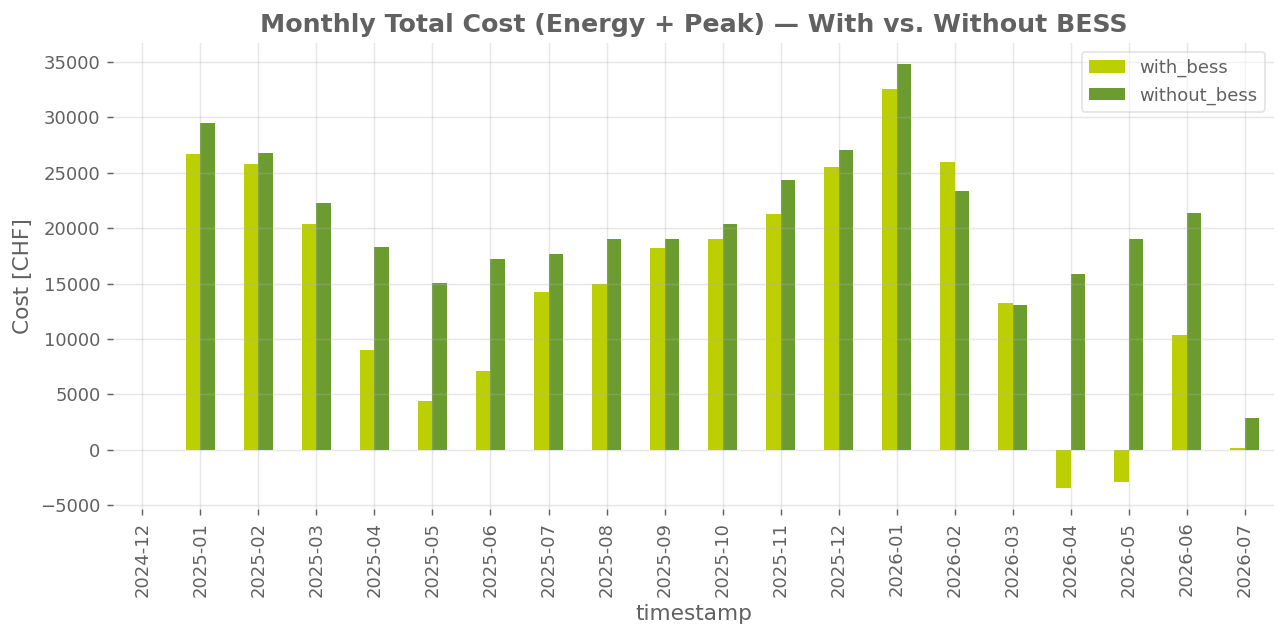

           with_bess  without_bess
timestamp                         
2024-12          NaN           NaN
2025-01      26654.0       29502.0
2025-02      25836.0       26814.0
2025-03      20380.0       22301.0
2025-04       8976.0       18281.0
2025-05       4366.0       15082.0
2025-06       7081.0       17210.0
2025-07      14279.0       17680.0
2025-08      14985.0       19005.0
2025-09      18174.0       19050.0
2025-10      19002.0       20402.0
2025-11      21280.0       24310.0
2025-12      25559.0       27061.0
2026-01      32527.0       34818.0
2026-02      25959.0       23327.0
2026-03      13226.0       13044.0
2026-04      -3444.0       15833.0
2026-05      -2879.0       19035.0
2026-06      10371.0       21328.0
2026-07        160.0        2840.0


In [17]:
# ── Graph 1: monthly peak loads, with vs. without BESS ───────────────────────
peaks_idx = peaks.copy()
peaks_idx.index = peaks_idx.index.astype(str)   # e.g. '2025-01' instead of a datetime/period

fig1, ax1 = plt.subplots(figsize=(10, 5), dpi=130)
peaks_idx.plot.bar(ax=ax1)
ax1.set_title("Monthly Peak Load — With vs. Without BESS", fontweight="bold")
ax1.set_ylabel("Peak power [MW]")
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── Graph 2: total load timeseries, with vs. without BESS ────────────────────
df_load_compare = pd.DataFrame({
    'load_without_bess': power_without_bess,
        'load_with_bess': power_with_bess,
})
plot_timeseries_columns(df_load_compare, df_load_compare.columns.tolist(),
                         title="Grid Power — With vs. Without BESS", ylabel="Power [MW]")
plt.show()

# ── Graph 3: total cost comparison — monthly & annual, incl. peak cost ──────
monthly_total_cost_idx = monthly_total_cost.copy()
monthly_total_cost_idx.index = monthly_total_cost_idx.index.astype(str)

fig3, ax3 = plt.subplots(figsize=(10, 5), dpi=130)
monthly_total_cost_idx.plot.bar(ax=ax3)
ax3.set_title("Monthly Total Cost (Energy + Peak) — With vs. Without BESS", fontweight="bold")
ax3.set_ylabel("Cost [CHF]")
ax3.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(monthly_total_cost.round(0))


In [12]:
#monthly_total_cost.to_csv(r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\monthly_total_costs_San_Antonino-front.csv')

C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\1884924857.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


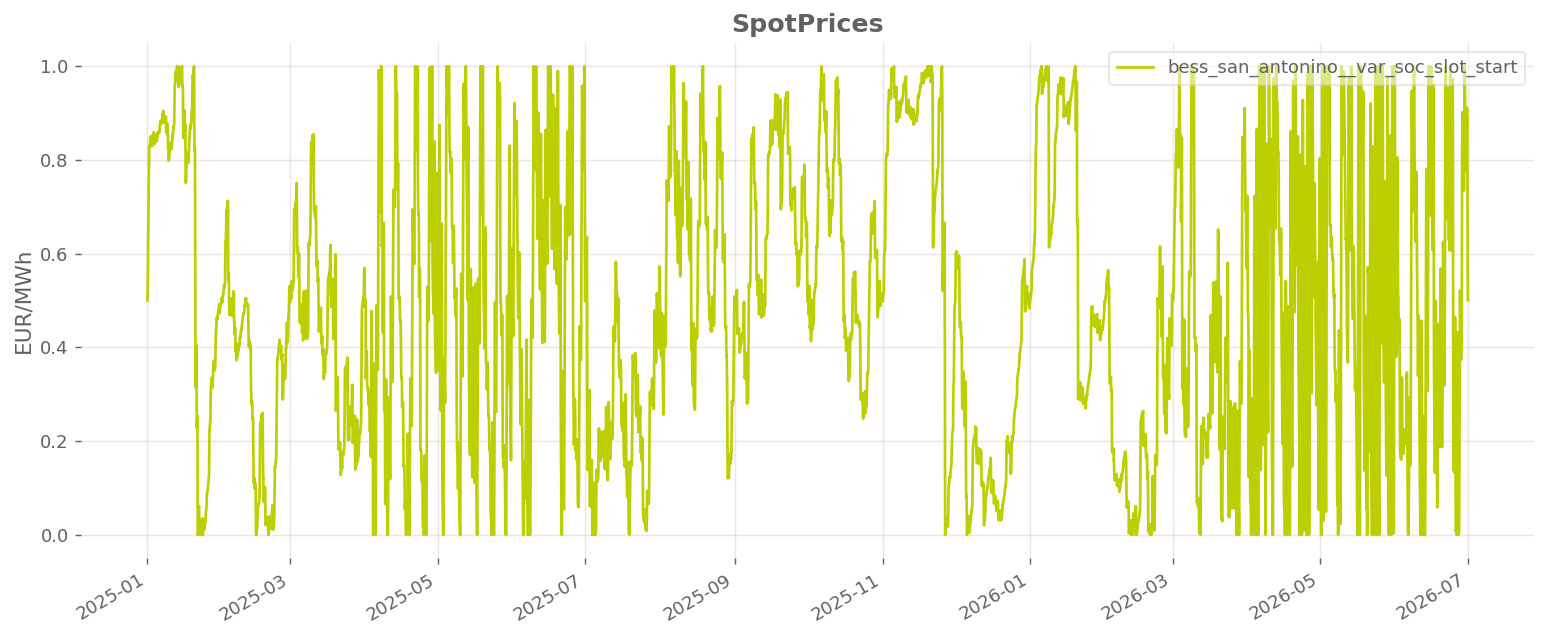

In [13]:
# columns
# PV_San_Antonino__var_power + San_Antonino__var_power, grid_peak_shave__var_power_export, -grid_peak_shave__var_power_import, spot_ch__var_power
# bess_san_antonino__var_power_charge, bess_san_antonino__var_power, bess_san_antonino__var_soc_slot_start, Spot CH [Euro/MWh]

plot_timeseries_columns(
    df_results,
    columns=['bess_san_antonino__var_soc_slot_start'],
    title="SpotPrices",
    ylabel="EUR/MWh",
)
plt.show()


C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_24748\1826633215.py:156: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


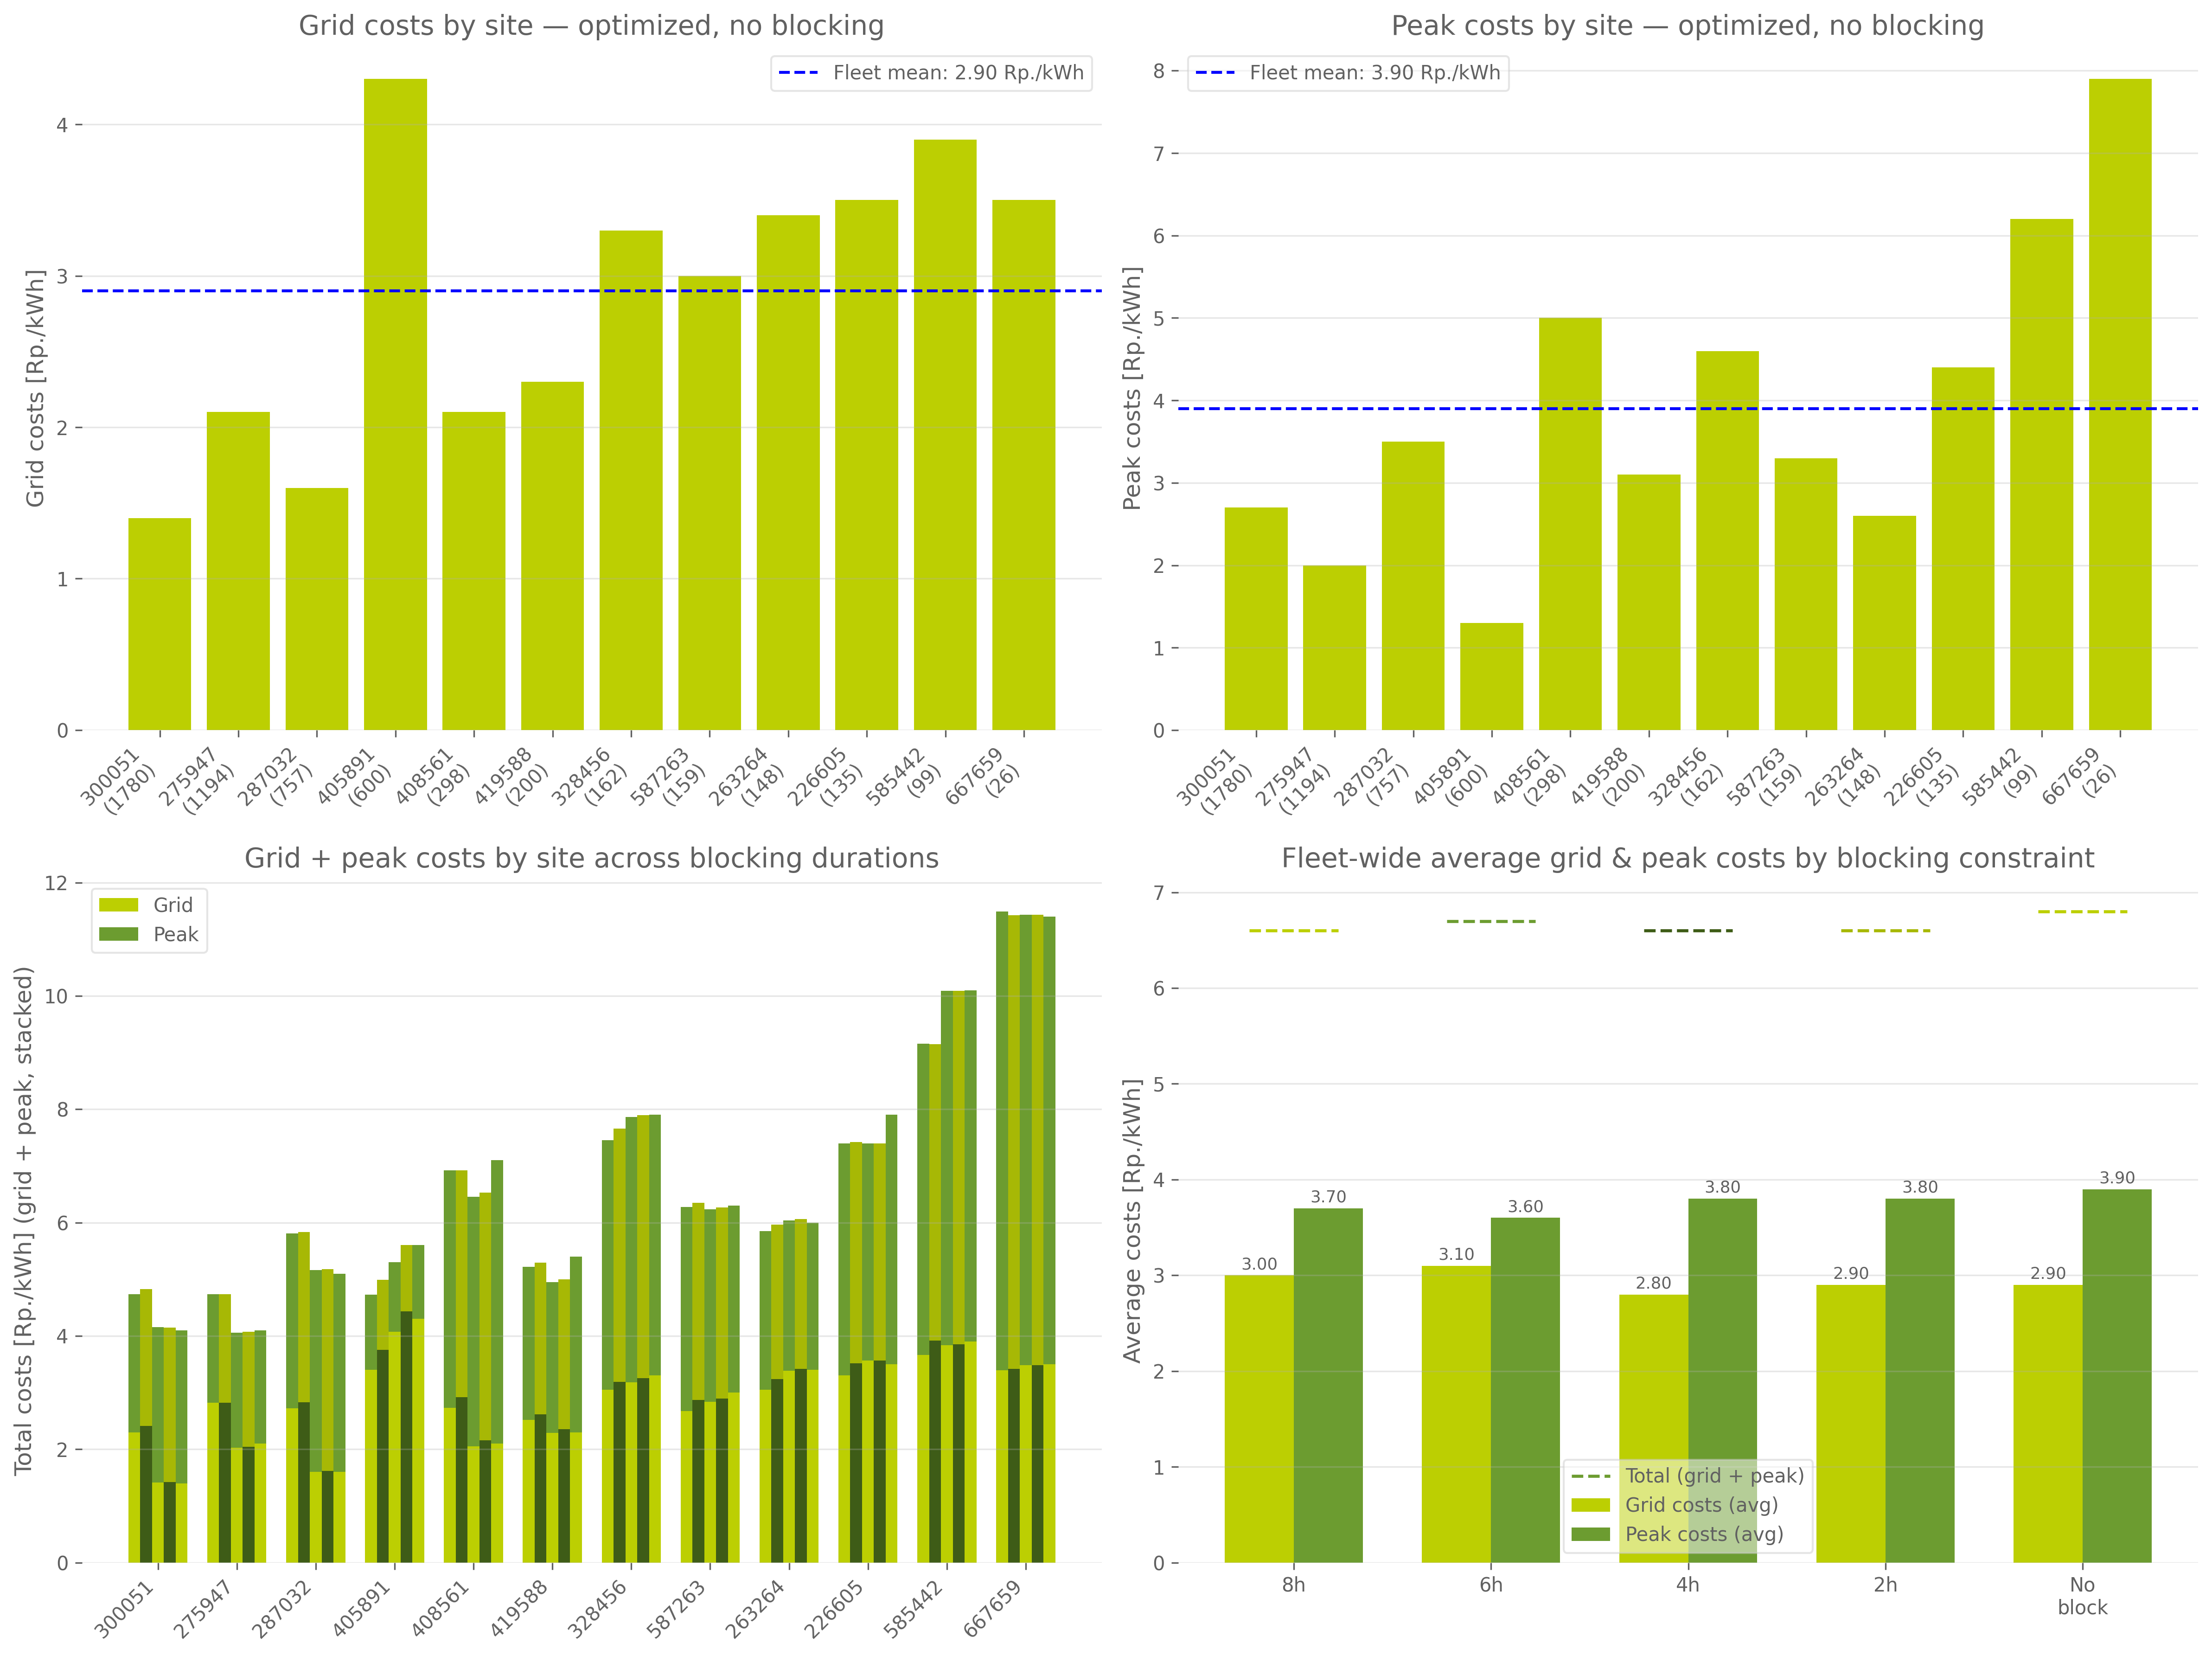

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl

# Set default plot properties (rcParams)
plt.rcParams['figure.figsize'] = [15, 8]  # Set the default figure size (width, height)
plt.rcParams['figure.dpi'] = 300  # Set the resolution (300 DPI for high-quality output)
plt.rcParams['lines.linewidth'] = 1     # Set default line width
plt.rcParams['lines.color'] = 'b'         # Set default line color (blue in this case)
plt.rcParams['axes.grid'] = True 
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.alpha'] = 0.3    
plt.rcParams['axes.titlecolor'] = '#616161'
plt.rcParams['axes.labelcolor'] = '#616161'
plt.rcParams['xtick.color'] = '#616161'
plt.rcParams['ytick.color'] = '#616161'
plt.rcParams['text.color'] = '#616161'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.markerscale'] = 1
plt.rcParams['legend.framealpha'] = 0.5
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#BCCF02", "#6C9C30", "#3E5C17", "#a7b805"]) 
# plt.rcParams["patch.facecolor"] = "#BCCF02"

plt.rcParams['figure.constrained_layout.use'] = True # alternativ zu tight_layout(). noch testen sonst deaktivieren

# ── Raw data (CHF/kWh) ───────────────────────────────────────────────────────
sites = [226605, 263264, 275947, 287032, 300051, 328456,
         405891, 408561, 419588, 585442, 587263, 667659]

grid_costs = pd.DataFrame({
    '8hrs blocked':  [0.033, 0.0305, 0.0282, 0.0272, 0.023, 0.0305, 0.034, 0.02728, 0.0252, 0.0366, 0.02671, 0.0339],
    '6hrs blocked':  [0.0352, 0.0324, 0.0282, 0.0283, 0.02415, 0.0319, 0.0375, 0.0292, 0.0262, 0.0392, 0.0287, 0.0342],
    '4hrs blocked':  [0.0356385, 0.0338226, 0.020302, 0.0160196, 0.0141036, 0.0317956, 0.0406938, 0.0205064, 0.0229161, 0.0383273, 0.0284116, 0.0348526],
    '2hrs blocked':  [0.0356385, 0.0341841, 0.0204713, 0.0162116, 0.0141845, 0.0325602, 0.0443007, 0.0215841, 0.0235403, 0.0385278, 0.0289204, 0.0348526],
    'No blocking':   [0.035, 0.034, 0.021, 0.016, 0.014, 0.033, 0.043, 0.021, 0.023, 0.039, 0.030, 0.035],
}, index=sites)

peak_costs = pd.DataFrame({
    '8hrs blocked':  [0.041, 0.028, 0.0192, 0.0309, 0.0244, 0.044, 0.0133, 0.0419, 0.027, 0.055, 0.036, 0.081],
    '6hrs blocked':  [0.039, 0.0272, 0.0192, 0.03, 0.0241, 0.0447, 0.0124, 0.04, 0.0267, 0.0523, 0.0348, 0.08],
    '4hrs blocked':  [0.03836, 0.02658, 0.0203, 0.03563, 0.02745, 0.04682, 0.01233, 0.04405, 0.02661, 0.0626, 0.03394, 0.07946],
    '2hrs blocked':  [0.03836, 0.02646, 0.02026, 0.03556, 0.02729, 0.04638, 0.01177, 0.04367, 0.02646, 0.0624, 0.03372, 0.07946],
    'No blocking':   [0.044, 0.026, 0.020, 0.035, 0.027, 0.046, 0.013, 0.050, 0.031, 0.062, 0.033, 0.079],
}, index=sites)

sessions = pd.Series({
    226605: 135, 263264: 148, 275947: 1194, 287032: 757, 300051: 1780,
    328456: 162, 405891: 600, 408561: 298, 419588: 200, 585442: 99,
    587263: 159, 667659: 26,
})

MEAN_GRID = {'8hrs blocked': 0.030, '6hrs blocked': 0.031, '4hrs blocked': 0.028,
             '2hrs blocked': 0.029, 'No blocking': 0.029}
MEAN_PEAK = {'8hrs blocked': 0.037, '6hrs blocked': 0.036, '4hrs blocked': 0.038,
             '2hrs blocked': 0.038, 'No blocking': 0.039}
MEAN_TOTAL = {'8hrs blocked': 0.066, '6hrs blocked': 0.067, '4hrs blocked': 0.066,
              '2hrs blocked': 0.066, 'No blocking': 0.068}

# ── Convert CHF/kWh -> Rp./kWh ───────────────────────────────────────────────
CHF_TO_RP = 100
grid_costs_rp = grid_costs * CHF_TO_RP
peak_costs_rp = peak_costs * CHF_TO_RP
mean_grid_rp  = {k: v * CHF_TO_RP for k, v in MEAN_GRID.items()}
mean_peak_rp  = {k: v * CHF_TO_RP for k, v in MEAN_PEAK.items()}
mean_total_rp = {k: v * CHF_TO_RP for k, v in MEAN_TOTAL.items()}

BLOCK_ORDER = ['8hrs blocked', '6hrs blocked', '4hrs blocked', '2hrs blocked', 'No blocking']
BLOCK_LABELS_SHORT = ['8h', '6h', '4h', '2h', 'No\nblock']

# Order sites by number of sessions (descending)
site_order = sessions.sort_values(ascending=False).index.tolist()

# ── Figure: 2x2 dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

x = np.arange(len(site_order))

# ── 1.1a: Grid costs per site, no-blocking, ranked by sessions ──────────────
grid_no_block = grid_costs_rp.loc[site_order, 'No blocking']
ax1.bar(x, grid_no_block.values)
ax1.axhline(mean_grid_rp['No blocking'], linestyle='--', linewidth=1.5,
            label=f"Fleet mean: {mean_grid_rp['No blocking']:.2f} Rp./kWh")
ax1.set_xticks(x)
ax1.set_xticklabels([f'{s}\n({sessions[s]})' for s in site_order], rotation=45, ha='right')
ax1.set_ylabel('Grid costs [Rp./kWh]')
ax1.set_title('Grid costs by site — optimized, no blocking')
ax1.legend()

# ── 1.1b: Peak costs per site, no-blocking, ranked by sessions ──────────────
peak_no_block = peak_costs_rp.loc[site_order, 'No blocking']
ax2.bar(x, peak_no_block.values)
ax2.axhline(mean_peak_rp['No blocking'], linestyle='--', linewidth=1.5,
            label=f"Fleet mean: {mean_peak_rp['No blocking']:.2f} Rp./kWh")
ax2.set_xticks(x)
ax2.set_xticklabels([f'{s}\n({sessions[s]})' for s in site_order], rotation=45, ha='right')
ax2.set_ylabel('Peak costs [Rp./kWh]')
ax2.set_title('Peak costs by site — optimized, no blocking')
ax2.legend()

# ── 1.2: Grid + peak costs per site across blocking durations ───────────────
n_sites = len(site_order)
n_scen = len(BLOCK_ORDER)
bar_w = 0.15
x_sites = np.arange(n_sites)

for i, scen in enumerate(BLOCK_ORDER):
    offset = (i - (n_scen - 1) / 2) * bar_w
    g_vals = grid_costs_rp.loc[site_order, scen].values
    p_vals = peak_costs_rp.loc[site_order, scen].values
    ax3.bar(x_sites + offset, g_vals, width=bar_w,
            label='Grid' if i == 0 else None)
    ax3.bar(x_sites + offset, p_vals, width=bar_w, bottom=g_vals,
            label='Peak' if i == 0 else None)

ax3.set_xticks(x_sites)
ax3.set_xticklabels(site_order, rotation=45, ha='right')
ax3.set_ylabel('Total costs [Rp./kWh] (grid + peak, stacked)')
ax3.set_title('Grid + peak costs by site across blocking durations')
ax3.legend()

# ── 1.3: Fleet-wide average per blocking constraint ─────────────────────────
x_scen = np.arange(len(BLOCK_ORDER))
w = 0.35
grid_means = [mean_grid_rp[s] for s in BLOCK_ORDER]
peak_means = [mean_peak_rp[s] for s in BLOCK_ORDER]
total_means = [mean_total_rp[s] for s in BLOCK_ORDER]

bars_g = ax4.bar(x_scen - w/2, grid_means, width=w, label='Grid costs (avg)')
bars_p = ax4.bar(x_scen + w/2, peak_means, width=w, label='Peak costs (avg)')

for xi, tv in zip(x_scen, total_means):
    ax4.plot([xi - w/2 - 0.05, xi + w/2 + 0.05], [tv, tv], linestyle='--', linewidth=1.6)
ax4.plot([], [], linestyle='--', linewidth=1.6, label='Total (grid + peak)')

for bars in (bars_g, bars_p):
    for b in bars:
        h = b.get_height()
        ax4.text(b.get_x() + b.get_width()/2, h + 0.03, f'{h:.2f}', ha='center', va='bottom', fontsize=8.5)

ax4.set_xticks(x_scen)
ax4.set_xticklabels(BLOCK_LABELS_SHORT)
ax4.set_ylabel('Average costs [Rp./kWh]')
ax4.set_title('Fleet-wide average grid & peak costs by blocking constraint')
ax4.legend()

plt.tight_layout()
plt.savefig('prices_dashboard_2025.png', dpi=150, bbox_inches='tight')
plt.show()


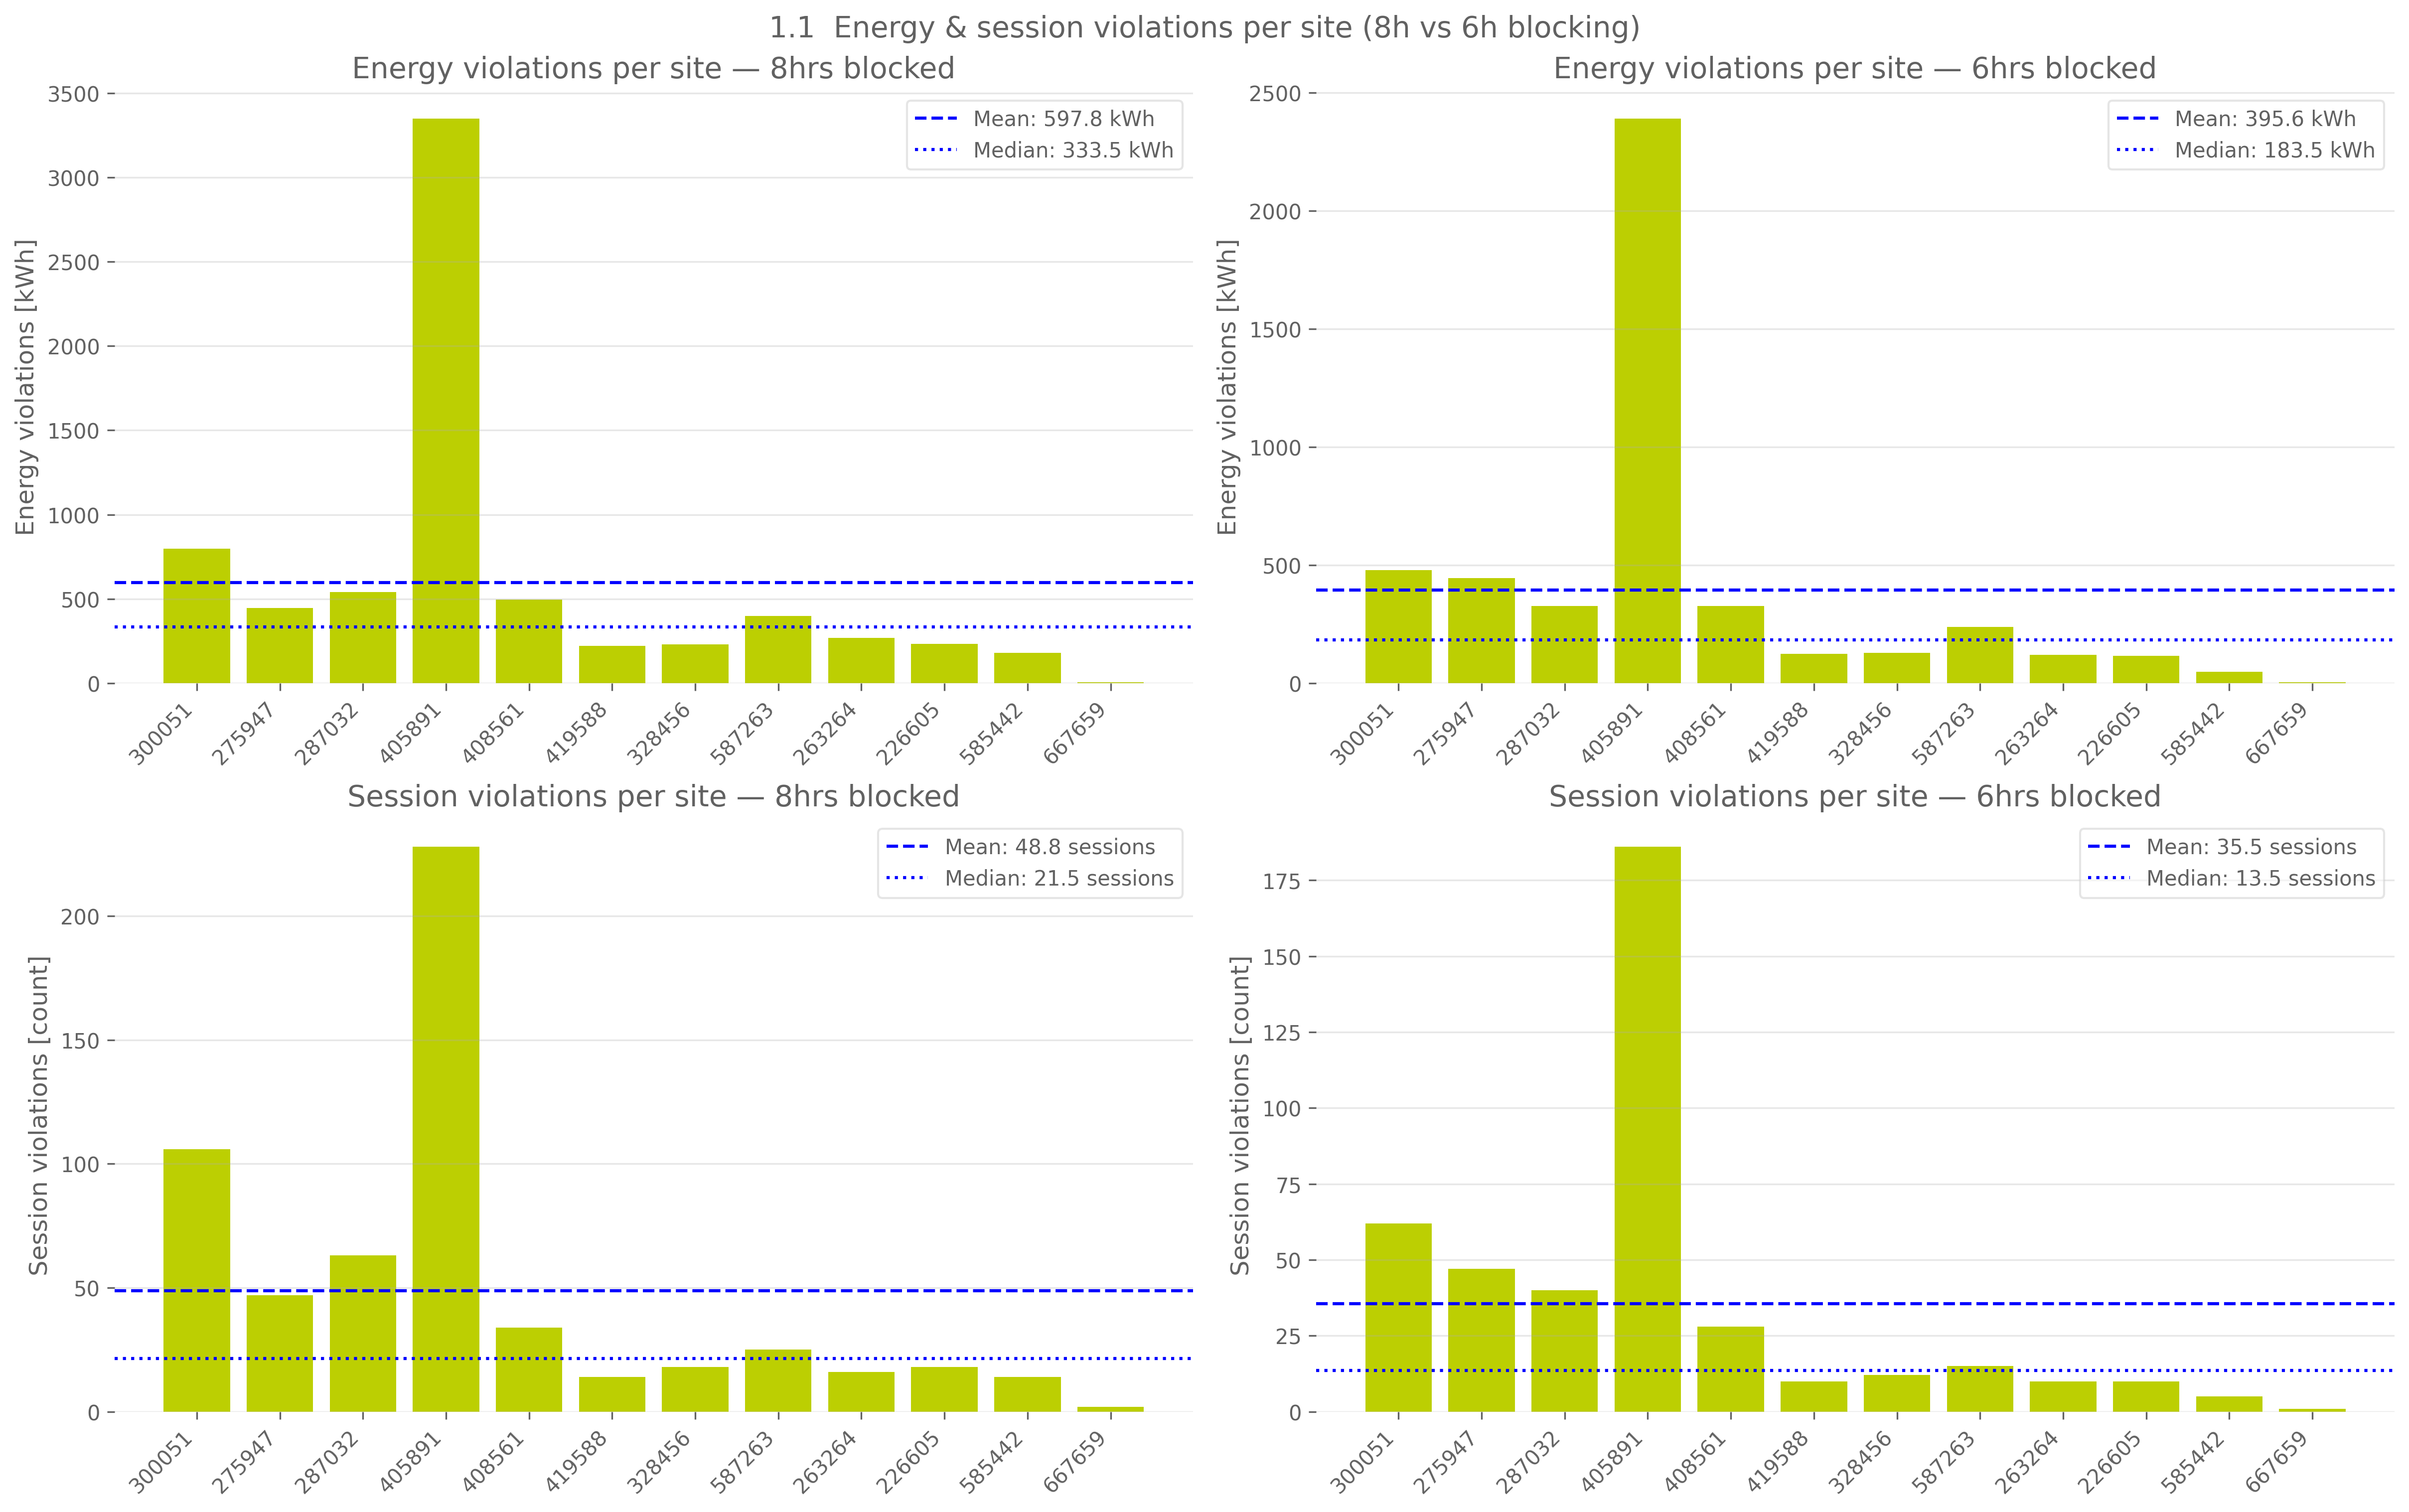

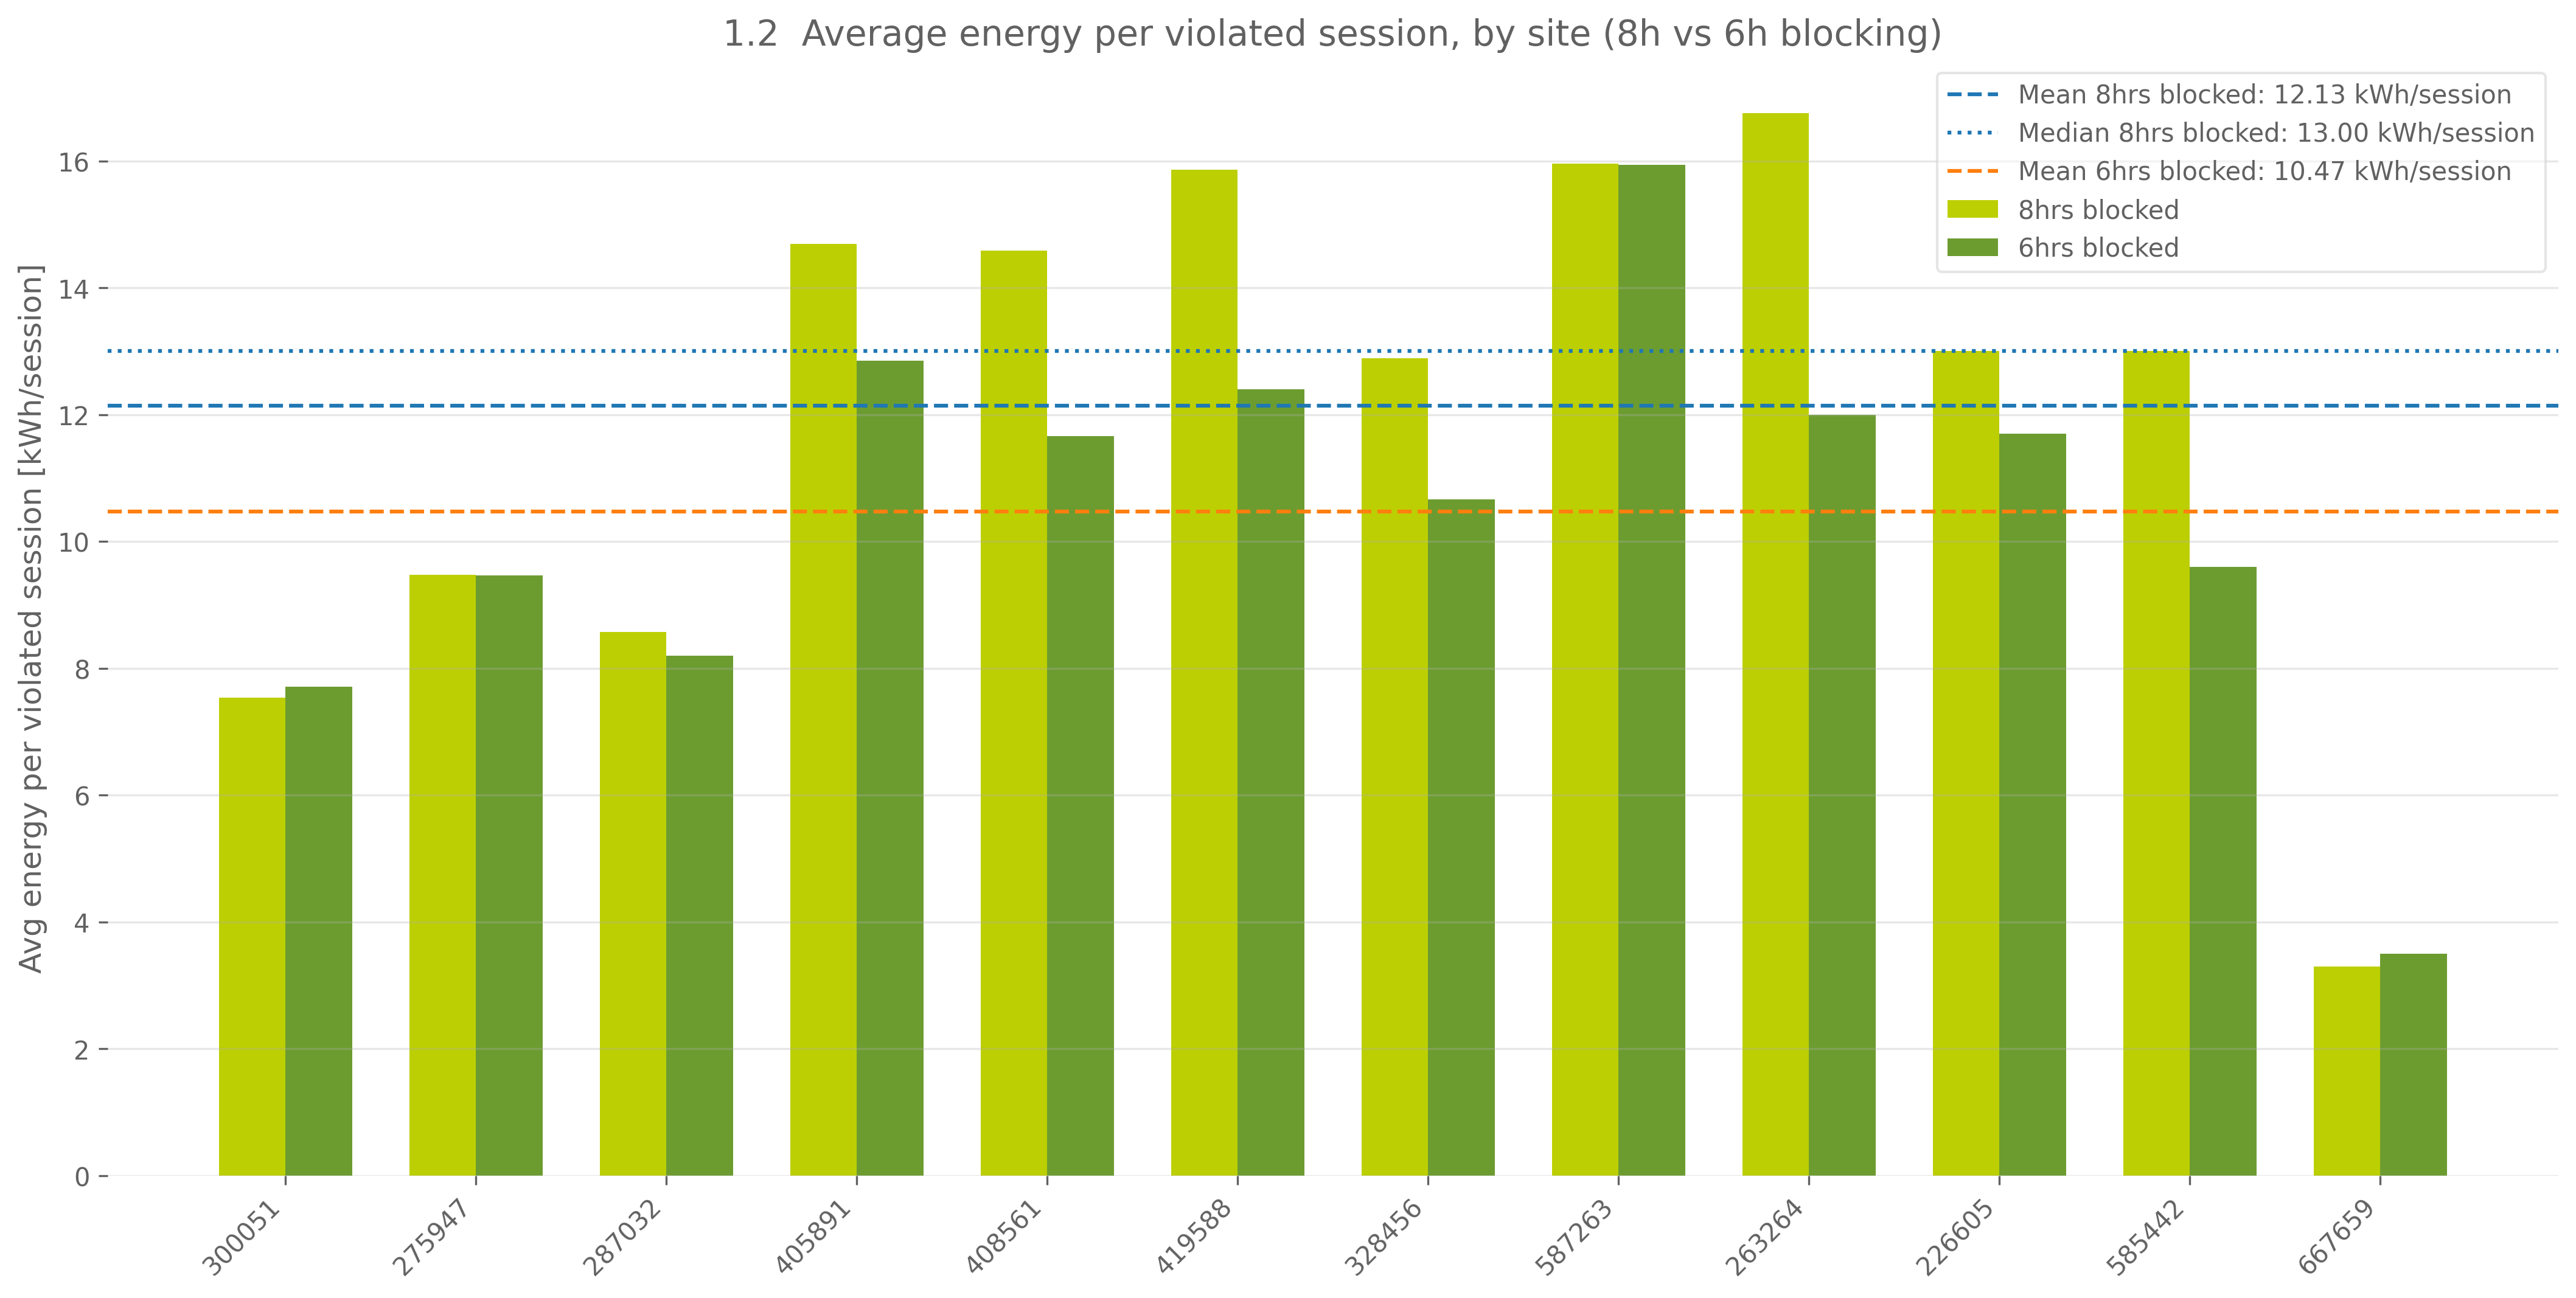

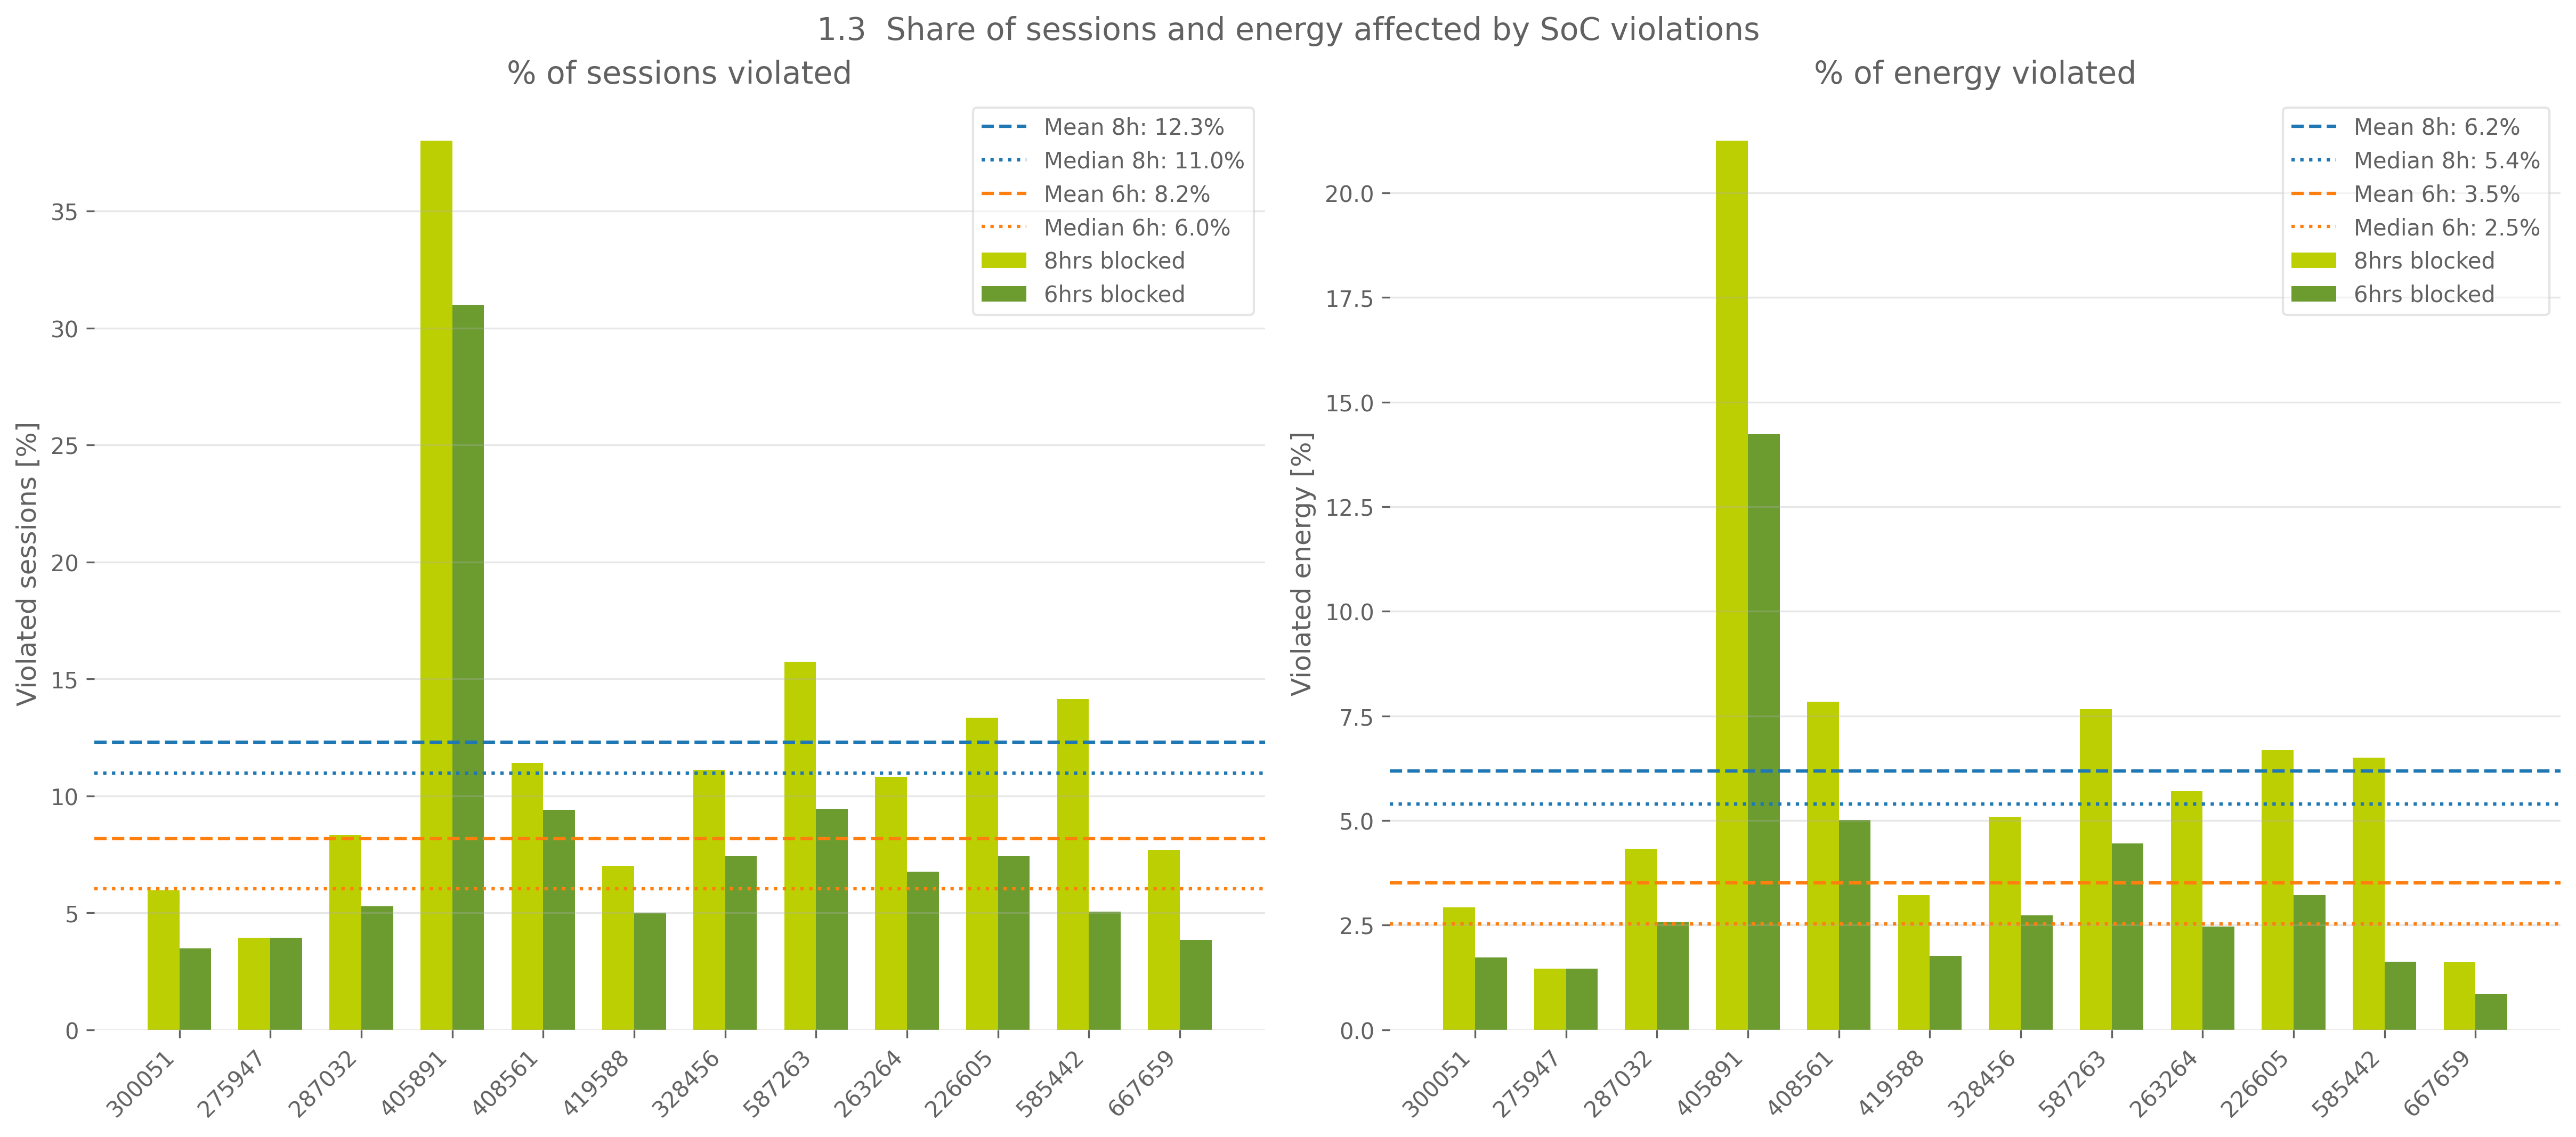

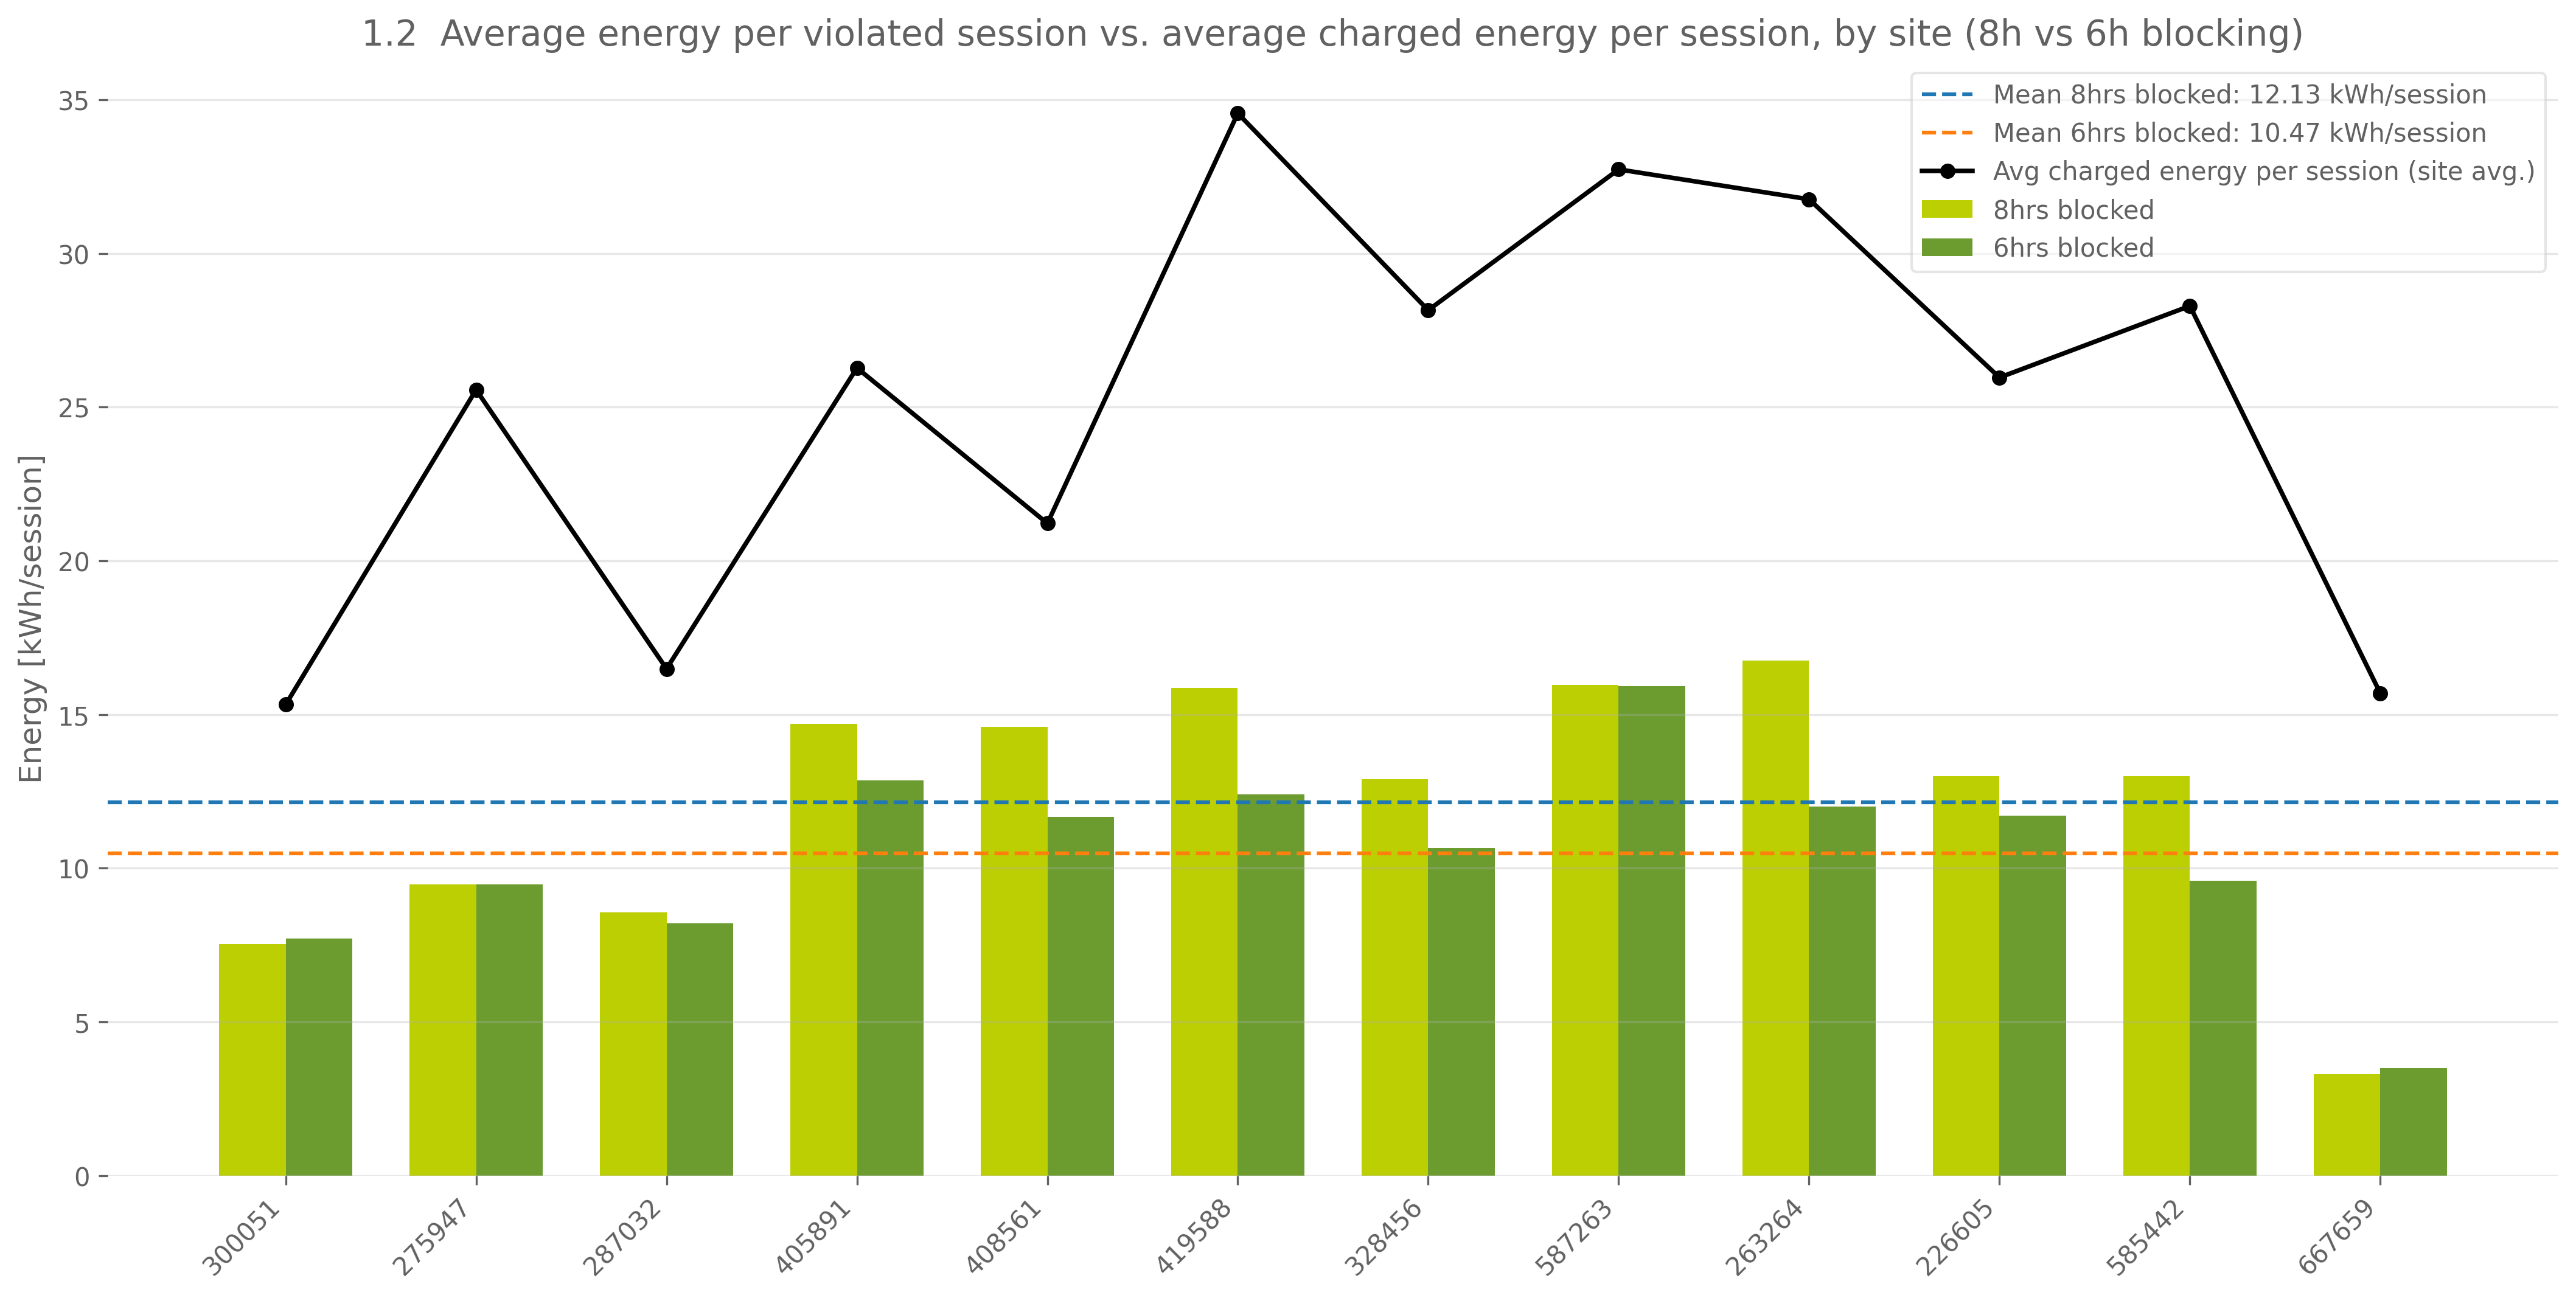

In [15]:
energy_violations = pd.DataFrame({
    '8hrs blocked': [234, 268, 445.42707, 540, 799, 232, 3349, 496, 222, 182, 399, 6.6],
    '6hrs blocked': [117, 120, 445, 328, 478, 128, 2390, 326.5, 124, 48, 239, 3.5],
}, index=sites)

session_violations = pd.DataFrame({
    '8hrs blocked': [18, 16, 47, 63, 106, 18, 228, 34, 14, 14, 25, 2],
    '6hrs blocked': [10, 10, 47, 40, 62, 12, 186, 28, 10, 5, 15, 1],
}, index=sites)

total_energy_charged = pd.DataFrame({
    '8hrs blocked': [3505.09, 4700.93, 30524.35, 12480.32, 27278.43, 4561, 15765.7, 6322.98, 6912, 2801, 5205, 408],
    '6hrs blocked': [3630.61, 4859, 30524, 12707, 27621, 4673, 16794, 6506, 7017, 2945, 5376, 411],
}, index=sites)

BLOCK_SCENARIOS = ['8hrs blocked', '6hrs blocked']

# ── Order sites by number of sessions (descending) ──────────────────────────
# Every plot below uses this order so sites are ranked consistently by
# session volume (busiest chargers first), matching the price dashboard.
site_order = sessions.sort_values(ascending=False).index.tolist()

energy_violations = energy_violations.loc[site_order]
session_violations = session_violations.loc[site_order]
total_energy_charged = total_energy_charged.loc[site_order]
total_sessions = sessions.loc[site_order]

# ── Derived metrics ──────────────────────────────────────────────────────────
avg_energy_per_violated_session = energy_violations / session_violations

pct_violated_sessions = session_violations.div(total_sessions, axis=0) * 100
pct_violated_energy = (energy_violations / total_energy_charged) * 100

# ══════════════════════════════════════════════════════════════════════════
# 1.1 — Energy violations & session violations per site, one plot per scenario
# ══════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, scenario in enumerate(BLOCK_SCENARIOS):
    ax_energy = axes1[0, col_idx]
    ax_session = axes1[1, col_idx]

    x = np.arange(len(site_order))

    # Energy violations per site
    ax_energy.bar(x, energy_violations[scenario].values)
    ax_energy.axhline(energy_violations[scenario].mean(), linestyle='--', linewidth=1.5,
                       label=f"Mean: {energy_violations[scenario].mean():.1f} kWh")
    ax_energy.axhline(energy_violations[scenario].median(), linestyle=':', linewidth=1.5,
                       label=f"Median: {energy_violations[scenario].median():.1f} kWh")
    ax_energy.set_xticks(x)
    ax_energy.set_xticklabels(site_order, rotation=45, ha='right')
    ax_energy.set_ylabel('Energy violations [kWh]')
    ax_energy.set_title(f'Energy violations per site — {scenario}')
    ax_energy.legend()

    # Session violations per site
    ax_session.bar(x, session_violations[scenario].values)
    ax_session.axhline(session_violations[scenario].mean(), linestyle='--', linewidth=1.5,
                        label=f"Mean: {session_violations[scenario].mean():.1f} sessions")
    ax_session.axhline(session_violations[scenario].median(), linestyle=':', linewidth=1.5,
                        label=f"Median: {session_violations[scenario].median():.1f} sessions")
    ax_session.set_xticks(x)
    ax_session.set_xticklabels(site_order, rotation=45, ha='right')
    ax_session.set_ylabel('Session violations [count]')
    ax_session.set_title(f'Session violations per site — {scenario}')
    ax_session.legend()

fig1.suptitle('1.1  Energy & session violations per site (8h vs 6h blocking)', fontsize=14)


# ══════════════════════════════════════════════════════════════════════════
# 1.2 — Avg energy per violated session, 8h vs 6h bars per site + mean
# ══════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(site_order))
w = 0.35

bars_8h = ax.bar(x - w/2, avg_energy_per_violated_session['8hrs blocked'].values, width=w,
                  label='8hrs blocked')
bars_6h = ax.bar(x + w/2, avg_energy_per_violated_session['6hrs blocked'].values, width=w,
                  label='6hrs blocked')

mean_8h = avg_energy_per_violated_session['8hrs blocked'].mean()
mean_6h = avg_energy_per_violated_session['6hrs blocked'].mean()
median_8h = avg_energy_per_violated_session['8hrs blocked'].median()
median_6h = avg_energy_per_violated_session['6hrs blocked'].median()

ax.axhline(mean_8h, color='tab:blue', linestyle='--', linewidth=1.5,
           label=f'Mean 8hrs blocked: {mean_8h:.2f} kWh/session')
ax.axhline(median_8h, color='tab:blue', linestyle=':', linewidth=1.5,
           label=f'Median 8hrs blocked: {median_8h:.2f} kWh/session')
ax.axhline(mean_6h, color='tab:orange', linestyle='--', linewidth=1.5,
           label=f'Mean 6hrs blocked: {mean_6h:.2f} kWh/session')
# ax.axhline(median_6h, color='tab:orange', linestyle=':', linewidth=1.5,
#            label=f'Median 6hrs blocked: {median_6h:.2f} kWh/session')

ax.set_xticks(x)
ax.set_xticklabels(site_order, rotation=45, ha='right')
ax.set_ylabel('Avg energy per violated session [kWh/session]')
ax.set_title('1.2  Average energy per violated session, by site (8h vs 6h blocking)')
ax.legend()


# ══════════════════════════════════════════════════════════════════════════
# 1.3 — % of violated sessions and % of violated energy, 8h vs 6h
# ══════════════════════════════════════════════════════════════════════════
fig3, (ax_sess, ax_energy) = plt.subplots(1, 2, figsize=(16, 7))

x = np.arange(len(site_order))
w = 0.35

# % violated sessions
ax_sess.bar(x - w/2, pct_violated_sessions['8hrs blocked'].values, width=w, label='8hrs blocked')
ax_sess.bar(x + w/2, pct_violated_sessions['6hrs blocked'].values, width=w, label='6hrs blocked')
ax_sess.axhline(pct_violated_sessions['8hrs blocked'].mean(), color='tab:blue', linestyle='--', linewidth=1.5,
                 label=f"Mean 8h: {pct_violated_sessions['8hrs blocked'].mean():.1f}%")
ax_sess.axhline(pct_violated_sessions['8hrs blocked'].median(), color='tab:blue', linestyle=':', linewidth=1.5,
                 label=f"Median 8h: {pct_violated_sessions['8hrs blocked'].median():.1f}%")
ax_sess.axhline(pct_violated_sessions['6hrs blocked'].mean(), color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f"Mean 6h: {pct_violated_sessions['6hrs blocked'].mean():.1f}%")
ax_sess.axhline(pct_violated_sessions['6hrs blocked'].median(), color='tab:orange', linestyle=':', linewidth=1.5,
                 label=f"Median 6h: {pct_violated_sessions['6hrs blocked'].median():.1f}%")
ax_sess.set_xticks(x)
ax_sess.set_xticklabels(site_order, rotation=45, ha='right')
ax_sess.set_ylabel('Violated sessions [%]')
ax_sess.set_title('% of sessions violated')
ax_sess.legend()

# % violated energy
ax_energy.bar(x - w/2, pct_violated_energy['8hrs blocked'].values, width=w, label='8hrs blocked')
ax_energy.bar(x + w/2, pct_violated_energy['6hrs blocked'].values, width=w, label='6hrs blocked')
ax_energy.axhline(pct_violated_energy['8hrs blocked'].mean(), color='tab:blue', linestyle='--', linewidth=1.5,
                   label=f"Mean 8h: {pct_violated_energy['8hrs blocked'].mean():.1f}%")
ax_energy.axhline(pct_violated_energy['8hrs blocked'].median(), color='tab:blue', linestyle=':', linewidth=1.5,
                   label=f"Median 8h: {pct_violated_energy['8hrs blocked'].median():.1f}%")
ax_energy.axhline(pct_violated_energy['6hrs blocked'].mean(), color='tab:orange', linestyle='--', linewidth=1.5,
                   label=f"Mean 6h: {pct_violated_energy['6hrs blocked'].mean():.1f}%")
ax_energy.axhline(pct_violated_energy['6hrs blocked'].median(), color='tab:orange', linestyle=':', linewidth=1.5,
                   label=f"Median 6h: {pct_violated_energy['6hrs blocked'].median():.1f}%")
ax_energy.set_xticks(x)
ax_energy.set_xticklabels(site_order, rotation=45, ha='right')
ax_energy.set_ylabel('Violated energy [%]')
ax_energy.set_title('% of energy violated')
ax_energy.legend()

fig3.suptitle('1.3  Share of sessions and energy affected by SoC violations', fontsize=14)




###########################################################################
avg_energy_per_session = total_energy_charged.div(total_sessions, axis=0)
# ══════════════════════════════════════════════════════════════════════════
# 1.2 — Avg energy per violated session, 8h vs 6h bars per site + mean
# ══════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(site_order))
w = 0.35

bars_8h = ax.bar(x - w/2, avg_energy_per_violated_session['8hrs blocked'].values, width=w,
                  label='8hrs blocked')
bars_6h = ax.bar(x + w/2, avg_energy_per_violated_session['6hrs blocked'].values, width=w,
                  label='6hrs blocked')

mean_8h = avg_energy_per_violated_session['8hrs blocked'].mean()
mean_6h = avg_energy_per_violated_session['6hrs blocked'].mean()
median_8h = avg_energy_per_violated_session['8hrs blocked'].median()
median_6h = avg_energy_per_violated_session['6hrs blocked'].median()

ax.axhline(mean_8h, color='tab:blue', linestyle='--', linewidth=1.5,
           label=f'Mean 8hrs blocked: {mean_8h:.2f} kWh/session')

ax.axhline(mean_6h, color='tab:orange', linestyle='--', linewidth=1.5,
           label=f'Mean 6hrs blocked: {mean_6h:.2f} kWh/session')


# Overall average charged energy per session, per site (context line — not
# split by scenario, since it reflects normal charging behaviour, not violations)
ax.plot(x, avg_energy_per_session['8hrs blocked'].values, color='black',
        marker='o', markersize=5, linewidth=1.8, linestyle='-',
        label='Avg charged energy per session (site avg.)')

ax.set_xticks(x)
ax.set_xticklabels(site_order, rotation=45, ha='right')
ax.set_ylabel('Energy [kWh/session]')
ax.set_title('1.2  Average energy per violated session vs. average charged energy per session, by site (8h vs 6h blocking)')
ax.legend()